# Stateful channels: stream and fixed-point semantics

A channel diagram is **stateful** when some of its outputs are fed back into its
inputs one time step later. Such a diagram carries two semantics, and this page
takes them in turn:

1. **feedback loops** — what `feedback` builds and what the memory is;
2. **stream semantics** — `one_step` and `unroll`, the behaviour at each
   finite time;
3. **fixed-point semantics** — `at_time` and the state the loop settles into,
   approximated by `fix` or computed by `eigen_fix` depending on the physics.

In [1]:
import numpy as np

from discopy.symmetric import Equation
from optyx import photonic
from optyx.channel import Channel, Discard, bit, qmode
from optyx.core import diagram

import warnings

warnings.filterwarnings("ignore", message="Trial error")  # cotengra probes for optional tree-builders

## 1. Feedback loops

`feedback` closes the last `mem` outputs into the last `mem` inputs, delayed by
one step. Here a photon enters at every step and the second output is fed back.

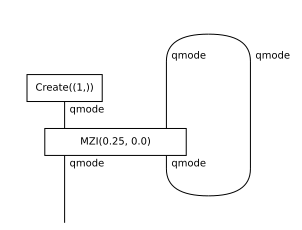

In [2]:
def loop(theta, phi=0.0):
    step = photonic.Create(1) @ qmode >> photonic.MZI(theta, phi)
    return step.feedback(mem=qmode, state=photonic.Create(0))


loop(.25).draw(figsize=(4, 3))

In [3]:
print(f"dom={loop(.25).dom}  cod={loop(.25).cod}  mem={loop(.25).mem}")

dom=Ty()  cod=qmode  mem=qmode


## 2. Stream semantics

`stream` returns a `Stream`: the underlying `discopy.stream.Stream` and one
`FeedbackBoundary` per loop, in the order `unroll` uses them.

In [4]:
loop_ = loop(.25)
print(f"mem={loop_.mem}  state={loop_.state}  effect={loop_.effect}")

mem=qmode  state=Create((0,))  effect=Discard


The boundary is the **memory wire only**. The inputs and outputs of each tick
stay open — they are the domain and codomain of the stream at that tick.

`now` opens every loop again: one tick, from `dom @ mem` to `cod @ mem`.

qmode -> qmode @ qmode


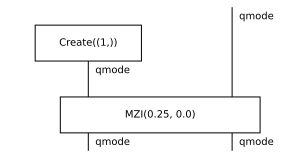

In [5]:
step = loop(.25).one_step()
print(f"{step.dom} -> {step.cod}")
step.draw(figsize=(4, 2))

`unroll(n)` unrolls `n` times — so `unroll(0)` is one tick — and plugs the
boundaries in, the `state` before the first tick and the `effect` after the
last. That is what the loop becomes:

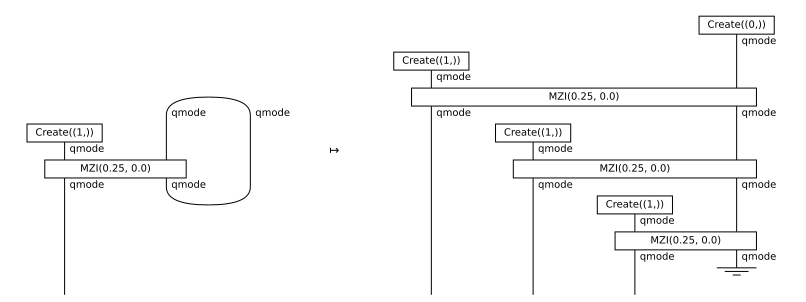

In [6]:
Equation(loop(.25), loop(.25).unroll(2), symbol=r"$\mapsto$").draw(
    figsize=(11, 4))

`stream` and `now` are methods, not properties. On a `discopy.stream.Stream`,
`now` and `mem` are fields of a value already built, so attribute syntax costs
nothing; only `later` is a property, and it forces the tail. Here nothing is
built yet: each call reinterprets the diagram to find the memory of every nested
loop, and a cached `.stream` property was considered and rejected, so attribute
syntax would promise a field and deliver a rebuild.

## 3. Fixed-point semantics

Both methods below need a **state** — an empty domain — and every loop needs a
`state`. `at_time(n)` iterates the loop with its output discarded, keeping only
the last, and counts iterations the way `unroll` counts unrollings: `at_time(0)`
is one tick.

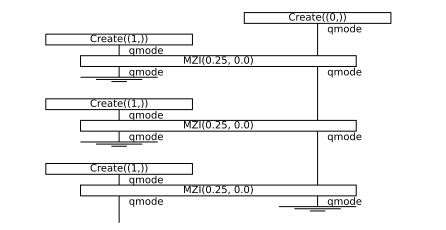

In [7]:
loop(.25).at_time(2).draw(figsize=(6, 3))

In [8]:
for n in (0, 1, 2, 7):
    measured = loop(.25).at_time(n) >> photonic.NumberResolvingMeasurement(1)
    p = measured.eval().prob_dist()
    print(f"ticks={n + 1}  " + "  ".join(f"p({k[0]})={v:.4f}" for k, v in
                                         sorted(p.items())[:4]))

ticks=1  p(0)=0.5000  p(1)=0.5000
ticks=2  p(0)=0.5000  p(1)=0.2500  p(2)=0.2500
ticks=3  p(0)=0.4688  p(1)=0.2812  p(2)=0.1563  p(3)=0.0938


ticks=8  p(0)=0.4466  p(1)=0.2741  p(2)=0.1601  p(3)=0.0825


`fix` runs a single tensor-network contraction of an unrolling and returns
the result as an `EvalResult`, so `density_matrix` and `prob_dist` read it
like any other evaluation. The depth comes from `unroll_certificate`, the
stationary boson-sampling bound of Armand Le Douarec, computed from the
loop's one-step optical matrix — loss included, since loss is part of the
diagram. Where the bound does not apply (qubit or classical memories, boxes
with no optical matrix), `fix` falls back on `power_fix`, which iterates
`at_time` and stops when successive states agree within the tolerance,
warning if `max_steps` arrives first. `fix` also warns separately when `chi`
truncates the contraction below the photon budget. `eigen_fix` skips the
unrolling altogether and diagonalises the transfer matrix of one step,
following [Biriukov and
Dyakonov (2026)](https://doi.org/10.48550/arXiv.2602.05566).

In [9]:
measured = loop(.06) >> photonic.NumberResolvingMeasurement(1)
stationary = measured.eigen_fix(chi=8)
print(type(stationary).__name__)
print("  ".join(f"p({k[0]})={v:.4f}"
                for k, v in sorted(stationary.prob_dist().items())[:5]))

EvalResult
p(0)=0.1241  p(1)=0.7587  p(2)=0.1105  p(3)=0.0067  p(4)=0.0000


In [10]:
def agreement(left, right):
    return max(abs(left.prob_dist().get(outcome, 0) - probability)
               for outcome, probability in right.prob_dist().items())


power = measured.fix(chi=None, max_steps=8)
print(f"agreement with eigen: {agreement(power, stationary):.2e}")

agreement with eigen: 3.49e-09


### Which approximation, and when

| method | what it does | truncation `chi` |
| --- | --- | --- |
| `fix` | one contraction of the unrolling, at the certified depth or at `max_steps` | bond dimension of the contraction; a photon budget past it warns that the result is truncated. `DEFAULT_CHI = 8` unless overridden; `None` is exact |
| `eigen_fix` | diagonalises the transfer matrix of one step | dimension of each memory wire; found from the photon budget when not given |

The physics decides. `eigen_fix` needs the memory cutoff to hold the whole
stationary tail, so it refuses a loop that retains photons — at $\theta=0.25$
the beam splitter is balanced, the tail is long, and no reachable `chi` is
enough. `fix` answers anyway, but says exactly what it could not promise: the
warning above flagged the uncertified depth, and here it also flags the
truncation, since eight steps of this loop already need nine dimensions.

In [11]:
balanced = loop(.25) >> photonic.NumberResolvingMeasurement(1)
try:
    balanced.eigen_fix(chi=16)
except ValueError as error:
    print(f"eigen: {error}")
print("  ".join(f"p({k[0]})={v:.4f}" for k, v in sorted(
    balanced.fix(max_steps=8).prob_dist().items())[:4]))

eigen: No cutoff below 32 truncates the transfer map without losing trace (residual 0.00024414062500022204 at 16); the tail is too long for this method.


/tmp/ipykernel_10577/3423326912.py:7: UserWarning: max_steps=8 stops before the stationary boson-sampling bound reaches tol=1e-06: the result is not certified.
  balanced.fix(max_steps=8).prob_dist().items())[:4]))


/tmp/ipykernel_10577/3423326912.py:7: UserWarning: the contraction needs dimension 9 but chi=8: the result is an approximation truncated at chi.
  balanced.fix(max_steps=8).prob_dist().items())[:4]))


p(0)=0.4466  p(1)=0.2741  p(2)=0.1601  p(3)=0.0825


`unroll_certificate` turns the loop itself into a certified depth: it reads
the one-step optical matrix off the loop's Stinespring dilation (`dilate`),
takes the loop-to-loop block $V_{ll}$, and returns the smallest $k$ with
$4K(\bar q)\sum_r \arcsin^2\sigma_r(V_{ll}^k) \leq tol$. A loss channel in
the loop shrinks the singular values of $V_{ll}$ by the amplitude it leaks,
so the same call certifies a shorter depth — loss is never a parameter.

In [12]:
for gamma in (.5, .9, .95):
    lossy = (loop(.25).arg >> qmode @ photonic.PhotonLoss(gamma)).feedback(
        mem=qmode, state=photonic.Create(0))
    print(f"gamma={gamma:.2f}  n* = {lossy.unroll_certificate(1e-6):4d}")

gamma=0.50  n* =   14
gamma=0.90  n* =   23
gamma=0.95  n* =   25


`truncation_dimensions` reads the photon budget of every output wire off the
diagram, which is the cutoff `eigen` diagonalises at when no `chi` is given.
It is not uniform: a photon only reaches the wires downstream of where it
enters.

In [13]:
chain = photonic.Create(1) @ photonic.Create(0) >> photonic.BS
for _ in range(3):
    tail = photonic.Id(1) @ photonic.Create(1) >> photonic.BS
    chain = chain >> photonic.Id(len(chain.cod) - 1) @ tail
print(f"budget: {chain.truncation_dimensions()}")

budget: [2, 2, 3, 3, 4, 4, 5, 5, 5, 5]


### Feedback boson sampling

Let $U$ be a number-preserving unitary on $M+L$ modes. Every step injects a fixed
Fock state on the $M$ external inputs, detects $M$ outputs and feeds $L$ back.

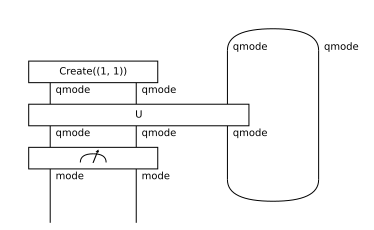

In [14]:
def haar(size, seed):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(size, size)) + 1j * rng.normal(size=(size, size))
    q, r = np.linalg.qr(z)
    return q * (np.diag(r) / np.abs(np.diag(r)))


M, L = 2, 1
U = photonic.Gate(haar(M + L, 7), M + L, M + L, "U")
sampler = (photonic.Create(*(1,) * M) @ qmode ** L >> U
           >> photonic.NumberResolvingMeasurement(M) @ qmode ** L
           ).feedback(mem=qmode ** L, state=photonic.Create(0))
sampler.draw(figsize=(5, 3))

One step holds both maps: discarding the detected modes gives the **transfer**
channel that updates the loop, $\rho\mapsto\operatorname{Tr}_M[U(\psi\otimes\rho)
U^\dagger]$; discarding the next memory gives the **readout**. `eigen_fix`
diagonalises the transfer map at the stationary memory $\rho_\star$, then reads
out once.

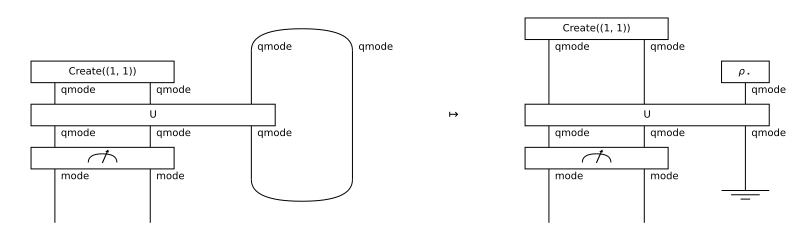

In [15]:
fixed = diagram.Box(r"$\rho_\star$", diagram.Ty(), diagram.Mode(2))
readout = (photonic.Create(*(1,) * M)
           @ Channel(r"$\rho_\star$", fixed, cod=qmode ** L,
                     env=diagram.Mode(1))
           >> U >> photonic.NumberResolvingMeasurement(M) @ Discard(qmode ** L))
Equation(sampler, readout, symbol=r"$\mapsto$").draw(figsize=(11, 3))

In [16]:
sampled = sampler.eigen_fix(chi=10)
for outcome, probability in sorted(
        sampled.prob_dist().items(), key=lambda item: -item[1])[:5]:
    print(f"p{outcome} = {probability:.4f}")
print(f"agreement with eight ticks: "
      f"{agreement(sampler.at_time(7).eval(), sampled):.2e}")

p(1, 0) = 0.1251
p(0, 0) = 0.1178
p(0, 1) = 0.1154
p(0, 2) = 0.1143
p(2, 0) = 0.1082


agreement with eight ticks: 6.66e-10


A real loop is a fibre, so each round trip transmits a fraction $\gamma$:
`PhotonLoss` puts that in the diagram, where every solver reads it — the
certificate through the dilated one-step matrix, `eigen_fix` through the
transfer channel. Nothing about loss is a solver input.

In [17]:
gamma = .5
lossy = (photonic.Create(*(1,) * M) @ qmode ** L >> U
         >> photonic.Id(M) @ photonic.PhotonLoss(gamma) ** L
         >> photonic.NumberResolvingMeasurement(M) @ qmode ** L
         ).feedback(mem=qmode ** L, state=photonic.Create(0))
print(f"certified depth at tol=1e-3: {lossy.unroll_certificate(1e-3)}")
certified = lossy.fix(tol=1e-3, chi=None)
print(f"agreement with eigen: "
      f"{agreement(certified, lossy.eigen_fix(chi=8)):.2e}")

certified depth at tol=1e-3: 5


agreement with eigen: 6.27e-08


That depth is read off the loop matrix itself, so it accounts for $U$ as
well as $\gamma$. The bound behind it and its proof are in the wiki notebook
*Bounding the unroll length in approximate stationary boson sampling*.

## Further reading

The setup is Yu. A. Biriukov and I. V. Dyakonov, [Simulation of boson sampling
with optical feedback](https://doi.org/10.48550/arXiv.2602.05566),
arXiv:2602.05566 (2026); for boson sampling itself, S. Aaronson and A. Arkhipov,
[The computational complexity of linear
optics](https://doi.org/10.1145/1993636.1993682), STOC 2011.

Delayed feedback of a monoidal stream is E. Di Lavore, G. de Felice and M. Román,
[Monoidal streams for dataflow
programming](https://doi.org/10.1145/3531130.3533365), LICS 2022 — the memory
wire is a delay, which is what makes this feedback rather than a trace in the
sense of P. Katis, N. Sabadini and R. F. C. Walters, *Feedback, trace and
fixed-point semantics*, RAIRO-ITA **36** (2002).